# Generar campo canonico mediante las detecciones de texto de SAM3

En este notebook hare la parte mas importante del proyecto, la cual es detectar y segmentar cada robot sin usar refinamiento, solo el SAM3 de base y su tracker. Asimismo, voy a generar el dibujo del campo canonico en la salida de video. 

Detalles:

    - Aun no se como diferenciar entre equipos
    
    - No recuerdo muy bien como se guardan los datos en CSV
    
    - No se exactamente como funciona el SAM3VideoSemanticPredictor ni la estructrura de los dato que regresa. 


Voy a dividir el notebook en las siguientes partes

1. Calcular la matriz de transformacion y visualizar la imagen en el primer frame
2. Calcular las coordenadas de cada robot y visualizarlas en el mapaTactico


## Como voy a guardar el archivo CSV?
En el archivo necesito que hayan los siguientes datos por cada frame. Planeo crear un archivo CSV independiente para cada objeto detectado. Debe de tener
1. Coordenadas
2. Velocidad en el frame
3. ID
4. Confianza

# 0. Importar paquetes y video

In [4]:
!pip install supervision -q
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.6/273.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.9 MB/s eta 0:00:00


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pathlib import Path
import supervision as sv
from google.colab.patches import cv2_imshow

#Librerias para tratar de manejar la memoria
import torch
import gc as garbageCollector

#Para guardar y exportar los datos
import pandas as pd


def cambiarColorBGRcv(imagen):
    return cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB)


rutaVideo = "/kaggle/input/datasets/jaguarnocturno/assets/VideoRobots-1min.mp4"
rutaImagen = "/kaggle/input/datasets/jaguarnocturno/assets/frameVideoRobots-1min.png"

#Mostrar datos de imagen y video
imagen = cv2.imread(rutaImagen)
ancho = imagen.shape[1]
alto = imagen.shape[0]

print("Ancho de imagen: ",ancho," pixeles.")
print("Alto de imagen",alto, " pixeles.")

Ancho de imagen:  1080  pixeles.
Alto de imagen 1920  pixeles.


In [6]:
#CALCULAR EL TAMANO EN PIXELES DE ACUERDO A LA ESCALA
w = 182 #medida en centimetros del alto de campo real
h = 243 #medida en centimetros del alto de campo real

for i in range(0,10):
    esc = (i+1)
    print(f"Escala={esc}==>   1 cm real = {esc} pixeles")
    print("Ancho mapa tactico: ", int(esc*w)," pixeles")
    print("Alto mapa tactico: ", int(esc*h), "pixeles")
    print("----------------------------")
    
    

Escala=1==>   1 cm real = 1 pixeles
Ancho mapa tactico:  182  pixeles
Alto mapa tactico:  243 pixeles
----------------------------
Escala=2==>   1 cm real = 2 pixeles
Ancho mapa tactico:  364  pixeles
Alto mapa tactico:  486 pixeles
----------------------------
Escala=3==>   1 cm real = 3 pixeles
Ancho mapa tactico:  546  pixeles
Alto mapa tactico:  729 pixeles
----------------------------
Escala=4==>   1 cm real = 4 pixeles
Ancho mapa tactico:  728  pixeles
Alto mapa tactico:  972 pixeles
----------------------------
Escala=5==>   1 cm real = 5 pixeles
Ancho mapa tactico:  910  pixeles
Alto mapa tactico:  1215 pixeles
----------------------------
Escala=6==>   1 cm real = 6 pixeles
Ancho mapa tactico:  1092  pixeles
Alto mapa tactico:  1458 pixeles
----------------------------
Escala=7==>   1 cm real = 7 pixeles
Ancho mapa tactico:  1274  pixeles
Alto mapa tactico:  1701 pixeles
----------------------------
Escala=8==>   1 cm real = 8 pixeles
Ancho mapa tactico:  1456  pixeles
Alto ma

# 1. Calcular matriz de transformacion

In [7]:
ESCALA = 8 #escala = a cuantos pixeles equivalen un centimetro

#PUNTOS MUESTRA
m1 = [50, 304]; o1 = [51*ESCALA,12*ESCALA]
#m2 = [576, 248]; o2 = [131*ESCALA,12*ESCALA]
m3 = [843, 208]; o3 = [170*ESCALA,12*ESCALA]

m4 = [1004, 1609]; o4 = [170*ESCALA,231*ESCALA]
#m5 =  [751, 1638]; o5 = [131*ESCALA,231*ESCALA]
m6 = [254, 1714]; o6 = [51*ESCALA,231*ESCALA]

#m7 = [216, 1437]; o7 = [41*ESCALA,186*ESCALA]
#m8 = [717, 1368]; o8 = [141*ESCALA,186*ESCALA]
#m9 = [608, 539]; o9 = [141*ESCALA,57*ESCALA]

#muestra = np.array([m1,m2,m3,m4,m5,m6,m7,m8,m9])
muestra = np.array([m1,m3,m4,m6])
muestra = np.float32(muestra)

#PUNTOS OBJETIVO

#objetivo = np.array([o1,o2,o3,o4,o5,o6,o7,o8,o9])
objetivo = np.array([o1,o3,o4,o6])
objetivo = np.float32(objetivo)

anchoMapa = ESCALA*182 #medida en pixeles del dibujo del mapa tactico
altoMapa = ESCALA*243

#Calcular matriz de homografica con RANSAC, el cual es robusto al ruido

H,inliers = cv2.findHomography(muestra,objetivo,cv2.RANSAC,3.0)
#H2 = cv2.getPerspectiveTransform(muestra,objetivo)



In [8]:
print(H)
print("-----------------")
print(inliers)

[[ 1.14741274e+00 -1.80942021e-01  4.01053893e+02]
 [ 1.36897422e-01  1.14115349e+00 -2.58833614e+02]
 [-1.71491640e-05 -3.41202393e-05  1.00000000e+00]]
-----------------
[[1]
 [1]
 [1]
 [1]]


## Visualizar la imagen transformada



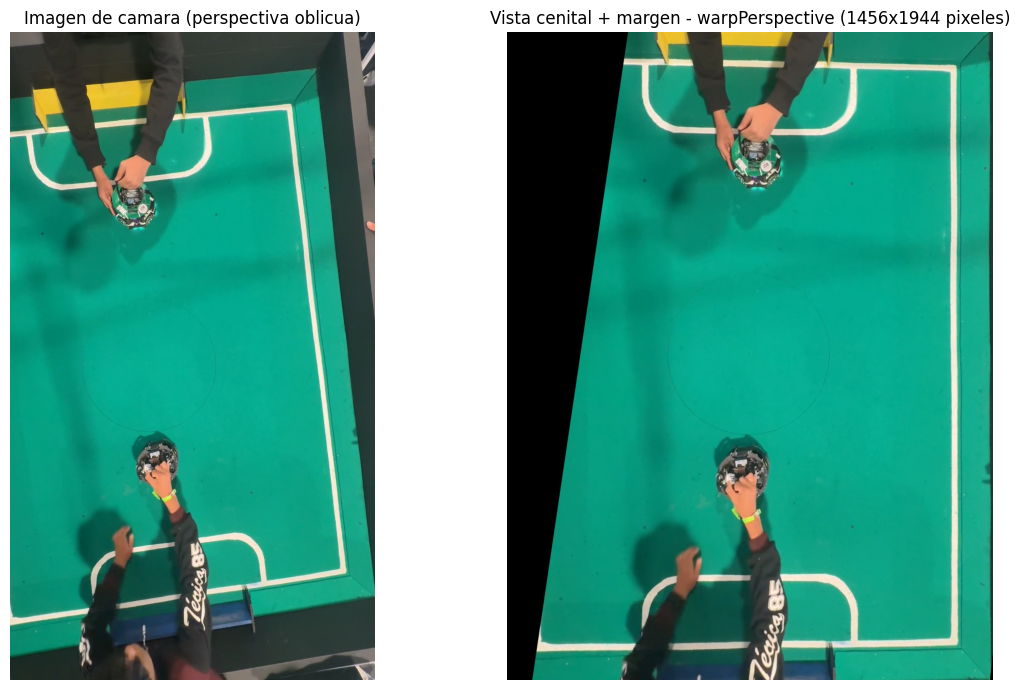

In [9]:
transformacion = imagen.copy()
transformacion = cv2.warpPerspective(transformacion,H,(anchoMapa,altoMapa))
#cv2_imshow(transformacion)

# Mostrar la imagen modificada
fig,ejes = plt.subplots(1,2,figsize=(12,7)
                                    #,gridspec_kw={"width_ratios": [600/1080,ancho_canvas//alto_canvas]}
                        )
#img = cv2.rotate(imagen.copy(), cv2.ROTATE_90_CLOCKWISE)
ejes[0].imshow(cambiarColorBGRcv(imagen.copy()))
ejes[0].set_title("Imagen de camara (perspectiva oblicua)",fontsize=12)
ejes[0].axis("off")

ejes[1].imshow(cambiarColorBGRcv(transformacion))
ejes[1].set_title(f"Vista cenital + margen - warpPerspective ({anchoMapa}x{altoMapa} pixeles)",fontsize=12)
ejes[1].axis("off")

plt.tight_layout()
plt.show()
plt.close('all')

# 2 crear funcion para dibujar el mapa tactico y elementos con OpenCV

## 2.2 Funcion para dibujar el mapa tactico

In [10]:
#VAMOS A CREAR EL MAPA TACTICO SIN LOS ROBOTS
def dibujar_mapa_tactico(ancho:int,alto:int):
    dimension = (alto,ancho,3)
       
    #Los colores usados estaran en formato BGR
    #Dibujar rectangulo contenedor, linea central y circulo central
    lienzo = np.zeros(dimension,dtype=np.uint8)
    lienzo[:] = (93,184,61) #Color verde oscuro en RGB

    #Rectangulo mas grande
    p1 = (int(ESCALA*12),int(ESCALA*12))
    p2 = (int(ESCALA*170),int(ESCALA*231))
    color = (255,255,255)
    cv2.rectangle(lienzo,p1,p2,color,10)

    #Linea de en medio
    p1 = (int(ESCALA*170),int(ESCALA*121.5))
    p2 = (int(ESCALA*12),int(ESCALA*121.5))
    color = (255,255,255)
    cv2.line(lienzo,p1,p2,color,4)

    #Circulo de enmedio
    centro = (int(ancho//2),int(alto//2))
    radio = int(30*ESCALA)
    color = (60,50,50)
    cv2.circle(lienzo,centro,radio,color,10)

    #LINEAS DE PENALTY
    p1 = (int(ESCALA*51),int(ESCALA*12))
    p2 = (int(ESCALA*131),int(ESCALA*37))
    color = (255,255,255)
    cv2.rectangle(lienzo,p1,p2,color,8)

    p1 = (int(ESCALA*51),int(ESCALA*206))
    p2 = (int(ESCALA*131),int(ESCALA*231))
    cv2.rectangle(lienzo,p1,p2,color,8)

    #ZONAS DE GOL
    p1 = (int(ESCALA*61),int(ESCALA*2))
    p2 = (int(ESCALA*121),int(ESCALA*12))
    color = (0,214,255)
    cv2.rectangle(lienzo,p1,p2,color,8)

    p1 = (int(ESCALA*61),int(ESCALA*231))
    p2 = (int(ESCALA*121),int(ESCALA*241))
    color = (217,68,65)
    cv2.rectangle(lienzo,p1,p2,color,8)

    #PUNTOS NEUTRALES
    n1 = (ESCALA*41,ESCALA*57)
    n2 = (ESCALA*141,ESCALA*57)
    n3 = (ESCALA*141,ESCALA*186)
    n4 = (ESCALA*41,ESCALA*186)
    radio = 10;color = (60,50,50)
    
    cv2.circle(lienzo,n1,radio,color,-1) #El -1 indica que se el circulo se rellena
    cv2.circle(lienzo,n2,radio,color,-1)
    cv2.circle(lienzo,n3,radio,color,-1)
    cv2.circle(lienzo,n4,radio,color,-1)


    
    


    return lienzo

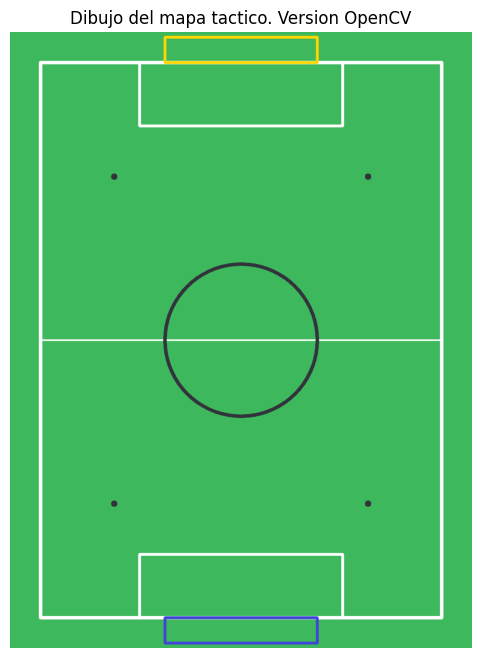

In [11]:
img = dibujar_mapa_tactico(anchoMapa,altoMapa)

plt.figure(figsize=(6,8))
plt.imshow(cambiarColorBGRcv(img))
plt.title("Dibujo del mapa tactico. Version OpenCV")
plt.axis("off")
plt.show()
plt.close("all")

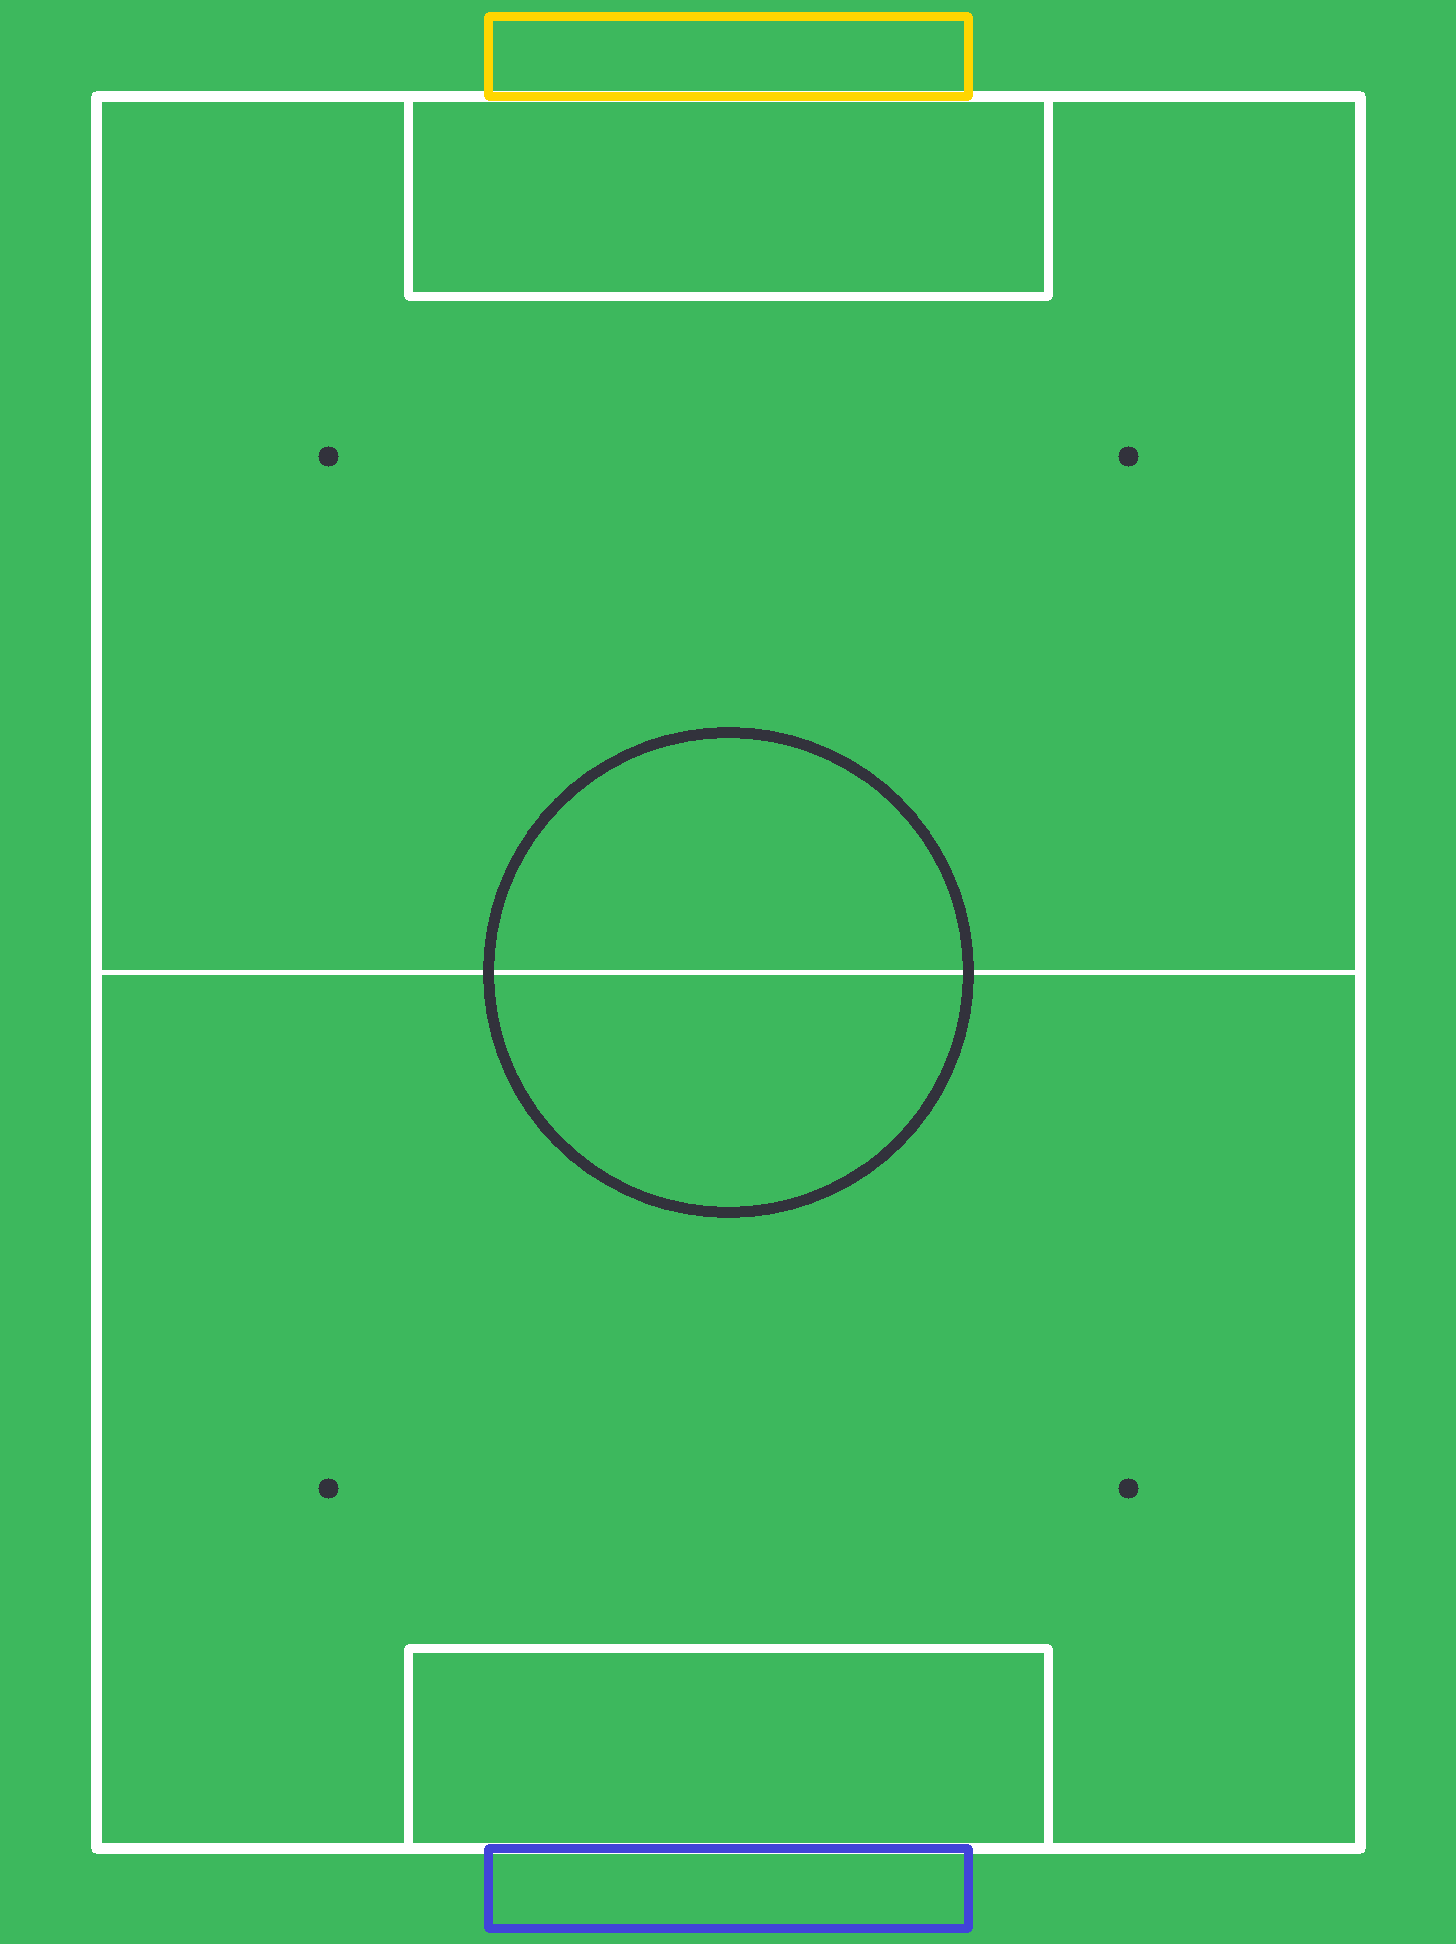

In [12]:
cv2_imshow(img)

## 2.1 Funcion para proyectar las detecciones al campo canonico

In [10]:
#La siguiente funcion recibe un objeto sv.Detections y una matriz H
#calcula el centro de la linea de abajo de la caja delimitadora
#y devuelve el punto correspondiente en el campo canonico

#NOTA: EN ESTA FUNCION PUDIERAMOS CREAR OTRO OBJETO SV.DETECTIONS PARA
#HACER LAS ANOTACIONES DE FORMA MAS FACIL EN EL CAMPO CANONICO

#Esta funcion devuelve una lista de diccionarios
#Cada diccionario corresponde a un objeto de sv.Detections
#Cada diccionario contiene las siguientes claves: posicion,class_name,tracker_id
def proyectar_detecciones(detecciones:sv.Detections,H:np.ndarray) -> list:
    puntos = []
    cajas = detecciones.xyxy
    tracker = detecciones.tracker_id.tolist()

    i = 0
    m = len(detecciones)
    for caja,tag_id in zip(cajas,tracker):
        #Se calcula el bottom center (tambien aplica para la pelota porque
        #buscamos proyectar un punto pegado al campo, que este en el mismo plano)
        #Mejor si calculemos el mero centro geometrico de cada caja
        
        x1=caja[0];y1=caja[1]
        x2=caja[2];y2=caja[3]

        x_bottom_center = (x1+x2)/2
        y_bottom_center = (y1+y2)/2

        punto = np.float32([x_bottom_center,y_bottom_center])
        proyeccion = cv2.perspectiveTransform(punto.reshape(1,1,2),H)
        puntos.append({
            "posicion":(   int(proyeccion[0][0][0])  ,  (int(proyeccion[0][0][1]) )),
            #"class_name": detecciones.data['class_name'].tolist()[i],
            "tracker_id": str(tag_id),
            #"numero_frame": 0,
            #"punto_anterior":0
        })
        i=i+1
    return puntos

#Esta funcion recibe la salida de la anterior y te da una lista de dos dimensiones con todoso
#los puntos, lo hago asi porque no quiero modificar la funcion anterior ni echar a perder
#todo el notebook
def obtener_lista_puntos(proyecciones):
    lista_x = []
    lista_y = []

    for punto in proyecciones:
        x = punto["posicion"][0]
        y = punto["posicion"][1]
        lista_x.append(x)
        lista_y.append(y)

    return [lista_x,lista_y]


    

In [13]:
#NOTA: Debo de poner la opcion para dibujar el diagrama de Voronoi
#NOTA: Debo verificar antes que las entradas no esten vacias

def dibujarRobots(imagen:np.ndarray,puntos_canonicos:list,color:tuple) -> np.ndarray:
    #Esta funcion recibe la imagen sobre la que se dibujaran los elementos
    #asi como la lista de puntos canonicos
    #recibe un color en formato BGR

    ancho_lienzo = imagen.shape[1]
    alto_lienzo = imagen.shape[0]

    for p in puntos_canonicos:
        x,y = p["posicion"]

        #Verificar que x,y se encuentren dentro del rango de coordenadas del lienzo
        if not (0<=x<=ancho_lienzo and 0<=y<=alto_lienzo ):
            continue #Si no estan dentro del rango de coordenadas, entonces se salta esta iteracion
        centro = (x,y)
        #color = (242,84,53)
        radio = 9*ESCALA #Suponiendo que el maximo tamano sea mas o menos 18 o 20 cm del robot
        cv2.circle(imagen,centro,radio,color,-1)
        cv2.circle(imagen,centro,radio,(255,255,255),3)
        #etiqueta = "Robot"
        
        etiqueta_id = p["tracker_id"]
        negro = (0,0,0)
        tipografia = cv2.FONT_HERSHEY_SIMPLEX
        fontScale=2
        thickness=3
        
        cv2.putText(imagen,etiqueta_id,(x,y),tipografia,fontScale,negro,thickness)
    return imagen

def dibujarPelota(imagen:np.ndarray,punto_canonico:list,color:tuple) -> np.ndarray:
    ancho_lienzo = imagen.shape[1]
    alto_lienzo = imagen.shape[0]

    for p in punto_canonico:
        x,y = p["posicion"]

        #Verificar que x,y se encuentren dentro del rango de coordenadas del lienzo
        if not (0<=x<=ancho_lienzo and 0<=y<=alto_lienzo ):
            continue 
        centro = (x,y)
        radio = 3*ESCALA #Suponiendo que el radio es 2cm
        cv2.circle(imagen,centro,radio,color,-1)
        cv2.circle(imagen,centro,radio,(255,255,255),1)
    return imagen


def procesarMascara(imagen_bgr):
    imagen = cv2.cvtColor(imagen_bgr,cv2.COLOR_BGR2HSV)
    naranja_inferior = np.array([7,225,130])
    naranja_superior = np.array([16,255,255])
    
    mascaraNormal = cv2.inRange(imagen,naranja_inferior,naranja_superior)
    mascaraProcesada = cv2.inRange(imagen,naranja_inferior,naranja_superior)

    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(15,15))
    kernel_open=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3))

    mascaraProcesada = cv2.morphologyEx(mascaraProcesada,cv2.MORPH_CLOSE,kernel_close)
    return mascaraProcesada
    


def detectarPelota(frame_bgr:np.ndarray,min_area:int = 50,max_area:int = 1000) -> sv.Detections:

    naranja_inferior = np.array([7,225,250])
    naranja_superior = np.array([16,255,255])

    frame = cv2.cvtColor(frame_bgr,cv2.COLOR_BGR2HSV)
    mascara = cv2.inRange(frame,naranja_inferior, naranja_superior )

    xyxy_list=[]
    class_ids=[]
    tracker_id = []
    nombres_clases = []

    kernel_open=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(9,9))
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(9,9))

    mascara = cv2.morphologyEx(mascara,cv2.MORPH_CLOSE,kernel_close)
    mascara = cv2.morphologyEx(mascara,cv2.MORPH_OPEN,kernel_open)
    
    mascara = procesarMascara(frame_bgr)
    contornos,valor = cv2.findContours(mascara,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    for cont in contornos:
        area = cv2.contourArea(cont)
        
        if(area>max_area or area<min_area):
            continue
            
        x,y,w,h_caja = cv2.boundingRect(cont)
        xyxy_list.append([x,y,x+w,y+h_caja])
        class_ids.append(0)
        tracker_id.append(-1)

    if not xyxy_list: return sv.Detections.empty()
  
    return sv.Detections(
    xyxy = np.array(xyxy_list,dtype=np.float32),
    class_id=np.array(class_ids,dtype=int),
    tracker_id=np.array(tracker_id,dtype=int)
  )

In [14]:
frame_confuso = cv2.imread("/kaggle/input/datasets/jaguarnocturno/assets/frameConfuso.png")
detecciones_pelota = detectarPelota(frame_confuso,50,1000)
print(detecciones_pelota)

Detections(xyxy=array([[396., 968., 420., 992.]], dtype=float32), mask=None, confidence=None, class_id=array([0]), tracker_id=array([-1]), data={}, metadata={})


# 2.2 Funciones para calcular la velocidad

Ok, posiblemente las siguientes funciones sean un poco redundantes porque ya tengo la funcion de proyectar_detecciones, pero realmente no quiero romperla ni echarla a perder, entonces hare una nueva, y luego veo como las unifico sin romper todo el flujo de procesamiento.

Tal vez haya una forma mas facil o elegante de ejecutar lo que hace la funcion `detecciones_sin_mascaras ` pero no la se en este momento, asi que me limitare a crear una funcion para que lo haga y mantener legible la ultima parte del flujo  (la cual tambien es la mas importante).

In [15]:
#La siguiente funcion solo extrae las cajas, confidence,class_id,tracker_id,data
#No guarda las mascaras
def detecciones_sin_mascaras(detecciones:sv.Detections)-> sv.Detections:
    xyxy = detecciones.xyxy
    confidence = detecciones.confidence
    class_id = detecciones.class_id
    tracker_id = detecciones.tracker_id
    data = detecciones.data

    return sv.Detections(xyxy=xyxy,confidence=confidence,class_id = class_id,tracker_id = tracker_id,data=data)


#En la siguiente escala es obviamente el valor del multiplicador de las medidas del campo original
#Aqui estamos suponiendo que los puntos entran en coordenadas de pixeles y devuelve la distancia euclidiana
#Otra suposicion es que son puntos que estan en el plano canonico\
import math
def calcular_distancia_euclidiana(punto1:tuple,punto2:tuple) -> float:
    x1=punto1[0];y1=punto1[1]
    x2=punto2[0]; y2=punto2[1]
    suma = (x1-x2)**2 +(y1-y2)**2
    distancia_pixeles = math.sqrt(suma)
    return distancia_pixeles


#La siguiente funcion recibe como entrada dos puntos, y el tiempo que los separa
#Escala es el numero de pixeles que caben en un centimetro
def calcular_velocidad_cm_segundo(punto_actual:tuple,punto_anterior:tuple,tiempo:float,escala:float) :
    distancia_pixeles = calcular_distancia_euclidiana(punto_actual,punto_anterior)
    distancia_centimetros = distancia_pixeles/escala
    velocidad = distancia_centimetros/tiempo
    return velocidad
    

def obtener_velocidades_por_identificador(detecciones_actuales,detecciones_anteriores,tiempo,matriz_transformacion):
    #Primero vamos a obtener los identificadores que esten en ambas detecciones
    #usando conjuntos

    trackers_actuales = detecciones_actuales.tracker_id.tolist()
    trackers_anteriores = detecciones_anteriores.tracker_id.tolist()
    
    A = set(trackers_actuales)
    B = set(trackers_anteriores)
    interseccion = A.intersection(B)
    interseccion = list(interseccion) #Aqui estan los tracker IDs que estan en ambos frames, es posible que sea interseccion vacia

    #Vamos a inicializar todas las velocidades con -1, luego se modifican
    numero_objetos = len(detecciones_actuales.tracker_id); 
    velocidades=[]
    for i in range(0,numero_objetos):
        velocidades.append(-1)

    #Vamos a obtener las posiciones de los objetos de cada frame
    puntos_actuales = proyectar_detecciones(detecciones_actuales,H)
    puntos_anteriores = proyectar_detecciones(detecciones_anteriores,H)


    #Ahora vamos a obtener los indices en cada deteccion
    indices_actuales=[]
    indices_anteriores=[]

    for identificador in interseccion:
        idx1 = trackers_actuales.index(identificador)
        idx2 = trackers_anteriores.index(identificador)
        
        p1 = puntos_actuales[idx1]['posicion']
        p2 = puntos_anteriores[idx2]['posicion']

        velocidad = calcular_velocidad_cm_segundo(p1,p2,tiempo,ESCALA)
        velocidades[idx1] = velocidad

    return velocidades

def obtener_etiquetas_velocidades(velocidades):
    etiquetas = []
    n = len(velocidades)

    #Vamos a inicializar la lista de etiquetas
    for v in velocidades:
        if(v == -1):
            etiquetas.append("-")
        else:
            v = v/10
            etiquetas.append(f"{v:.2f} dm/s")
    return etiquetas

## 2.2 Funciones para guardar los datos en un dataframe

Ok, antes de que corra el video crearemos un dataframe, en el cual vamos a guardar los siguientes datos:

- Numero de Frame
- Tracker_ID
- X_canonico
- Y_canonico

In [16]:
import pandas as pd


dataframe_global = pd.DataFrame( {
    "frame":[],
    "tracker_id":[],
    "class_name":[],
    "x_canon":[],
    "y_canon":[]
} )

# 3 Probar la homografia con segmentacion conceptual de SAM 3 (en primer frame) y proyectar al mapaTactico

In [17]:
'''
#IMPORTAR EL MODELO PARA HACER LA PREDICCION SEMANTICA EN LA IMAGEN
import torch
from ultralytics import SAM
from ultralytics.models.sam import SAM3SemanticPredictor


rutaModelo = "/kaggle/input/models/jaguarnocturno/s3o/pytorch/default/1/s3.pt"
configuracion  = dict(conf=0.35,
                     task="segment",
                     mode="predict",
                     model=rutaModelo,
                     verbose=True)
if torch.cuda.is_available():
    configuracion["half"] = True,
    configuracion["device"] = "cuda"

#Construir el predicto semantico
predictor_semantico = SAM3SemanticPredictor(overrides=configuracion)
'''

'\n#IMPORTAR EL MODELO PARA HACER LA PREDICCION SEMANTICA EN LA IMAGEN\nimport torch\nfrom ultralytics import SAM\nfrom ultralytics.models.sam import SAM3SemanticPredictor\n\n\nrutaModelo = "/kaggle/input/models/jaguarnocturno/s3o/pytorch/default/1/s3.pt"\nconfiguracion  = dict(conf=0.35,\n                     task="segment",\n                     mode="predict",\n                     model=rutaModelo,\n                     verbose=True)\nif torch.cuda.is_available():\n    configuracion["half"] = True,\n    configuracion["device"] = "cuda"\n\n#Construir el predicto semantico\npredictor_semantico = SAM3SemanticPredictor(overrides=configuracion)\n'

In [18]:
'''
#Cargar la imagen a la memoria
import time
inicio = time.time()

predictor_semantico.set_image(imagen)

fin = time.time()
diferencia = fin-inicio
print("Imagen cargada correctamente.")
print("Tiempo total: ",diferencia, " segundos.")
'''

'\n#Cargar la imagen a la memoria\nimport time\ninicio = time.time()\n\npredictor_semantico.set_image(imagen)\n\nfin = time.time()\ndiferencia = fin-inicio\nprint("Imagen cargada correctamente.")\nprint("Tiempo total: ",diferencia, " segundos.")\n'

In [19]:
'''
#Ejecutar inferencias
prompt = ["small robot","orange sphere"]
resultados = predictor_semantico(text=prompt)[0]
detecciones = sv.Detections.from_ultralytics(resultados)
'''

'\n#Ejecutar inferencias\nprompt = ["small robot","orange sphere"]\nresultados = predictor_semantico(text=prompt)[0]\ndetecciones = sv.Detections.from_ultralytics(resultados)\n'

In [20]:
'''
##GRAFICAR LAS SEGMENTACIONES
anotador_mascara = sv.MaskAnnotator(opacity=0.90,color_lookup=sv.ColorLookup.INDEX)
anotador_caja = sv.BoxAnnotator(thickness=2,color_lookup=sv.ColorLookup.INDEX)

escena = imagen.copy()
escena = anotador_mascara.annotate(scene=escena,detections=detecciones)
escena = anotador_caja.annotate(scene=escena,detections=detecciones)

cv2_imshow(escena)
'''

'\n##GRAFICAR LAS SEGMENTACIONES\nanotador_mascara = sv.MaskAnnotator(opacity=0.90,color_lookup=sv.ColorLookup.INDEX)\nanotador_caja = sv.BoxAnnotator(thickness=2,color_lookup=sv.ColorLookup.INDEX)\n\nescena = imagen.copy()\nescena = anotador_mascara.annotate(scene=escena,detections=detecciones)\nescena = anotador_caja.annotate(scene=escena,detections=detecciones)\n\ncv2_imshow(escena)\n'

## Proyectar robots al mapa tactico

In [21]:
'''
robots = detecciones[detecciones.data['class_name']=='small robot']
pelota = detecciones[detecciones.data['class_name']=='orange sphere']

puntos_robots = proyectar_detecciones(robots,H)
punto_pelota = proyectar_detecciones(pelota,H)

print("Elementos en puntos robots: ",len(puntos_robots))
print("Elementos en puntos pelota: ",len(punto_pelota))


mapa = dibujar_mapa_tactico(anchoMapa,altoMapa)

color = (242,84,53)#azulMarino en BGR
mapa = dibujarRobots(mapa,puntos_robots,color)

color = (49,121,245) #Naranaja en BGR
mapa = dibujarPelota(mapa,punto_pelota,color)

cv2_imshow(mapa)
'''

'\nrobots = detecciones[detecciones.data[\'class_name\']==\'small robot\']\npelota = detecciones[detecciones.data[\'class_name\']==\'orange sphere\']\n\npuntos_robots = proyectar_detecciones(robots,H)\npunto_pelota = proyectar_detecciones(pelota,H)\n\nprint("Elementos en puntos robots: ",len(puntos_robots))\nprint("Elementos en puntos pelota: ",len(punto_pelota))\n\n\nmapa = dibujar_mapa_tactico(anchoMapa,altoMapa)\n\ncolor = (242,84,53)#azulMarino en BGR\nmapa = dibujarRobots(mapa,puntos_robots,color)\n\ncolor = (49,121,245) #Naranaja en BGR\nmapa = dibujarPelota(mapa,punto_pelota,color)\n\ncv2_imshow(mapa)\n'

# 4. Aplicar la homografia a un video completo y exportarlo junto con el mapa tactico

Con una escala = 8. La medida en pixeles del mapa tactico seria

* Alto = 1944
* Ancho = 1456

Mientras que el video original tiene medidas de:

* Alto = 1920
* Ancho = 1080

_~~Luego de hacerle una rotacion de 90 grados en sentido antihorario al mapa Tactico tendriamos la siguiente comparacion entre el original y el mapa tactico~~_

Sin hacer rotaciones al mapa tactico tendriamos las siguientes comparaciones

----------------------

* **ancho_video_original** = 1080
* **ancho_mapa_tactico** = 1456
----------------------
* **alto_video_original** = 1920
* **alto_mapa_tactico** = 1944
---------------------------

Entonces tendremos que reducir el ancho del frame del mapa tactico de tal forma que tengan las mismas medidas, es decir, que su alto y ancho se multiplican por una proporcion: 

```

proporcion = alto_video_original/alto_mapa_tactico

alto_final_frame_mapa = int(ancho_mapa_tactico*proporcion)
ancho_final_frame_mapa = int(ancho_mapa_tactico*proporcion)
```
Y las medidas del video definitivo de salida son
```
ancho_salida_video = ancho_video_original + ancho_final_frame_mapa
alto_salida_video = alto_video_original
```



## Uso de np.hstack y np.vstack para concatenar frames
La imagen fue obtenida de StackOverflow
![](https://i.sstatic.net/hSM5G.png)

In [22]:
#Queremos que al final se cumpla que, luego de la rotacion del mapa tactico en sentido antihorario
# Ancho Mapa = Ancho Original = 1920
# AltoMapa y AltoOriginal pueden diferir

ancho_video_original = imagen.shape[1]
alto_video_original = imagen.shape[0]

#Los siguientes son los valores sin rotacion
alto_mapa_tactico = ESCALA*243
ancho_mapa_tactico = ESCALA*182

#Le vamos a aplicar un reshape para que su ancho de salida sea de
#Ancho = 1920
#proporcion = 1920/1944
#alto = ancho*proporcion

proporcion =alto_video_original/alto_mapa_tactico

anchoMapa_test_salida = int(proporcion*ancho_mapa_tactico)
altoMapa_test_salida = int(proporcion*alto_mapa_tactico)

print("Medida final de salida altoMapa: ",altoMapa_test_salida)
print("Medida final de salida anchoMapa: ",anchoMapa_test_salida)

Medida final de salida altoMapa:  1920
Medida final de salida anchoMapa:  1438


## 4.1 Importar librerias y el video a analizar

In [23]:
from ultralytics.models.sam import SAM3VideoSemanticPredictor
import torch

#rutaVideo = "/kaggle/input/datasets/jaguarnocturno/assets/VideoRobots-1min.mp4"


#IMPRIMIR INFORMACION DEL VIDEO
info = sv.VideoInfo.from_video_path(rutaVideo)

print(f"Resolucion: {info.width} x {info.height}")
print(f"FPS: {info.fps}")
print(f"Frames totales: {info.total_frames}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Resolucion: 1080 x 1920
FPS: 29.97002997002997
Frames totales: 1778


In [24]:
cap = cv2.VideoCapture(rutaVideo)
fps = cap.get(cv2.CAP_PROP_FPS)
ancho_original = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
alto_original = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)  )

#Calcular el ancho de salida del frame del mapaTactico
ancho_mapa_tactico = anchoMapa
alto_mapa_tactico = altoMapa

proporcion = alto_original/alto_mapa_tactico

altoSalida_mapa = int(proporcion*alto_mapa_tactico)
anchoSalida_mapa = int(proporcion*ancho_mapa_tactico)

#print(altoSalida_mapa)
#print(anchoSalida_mapa)

    
ancho_salida_video = ancho_original + anchoSalida_mapa
alto_salida_video = alto_original

print("Alto salida de video: ",alto_salida_video)
print("Ancho salida de video: ",ancho_salida_video)

#INICIALIZAR ANOTADORES PARA EL VIDEO
anotador_mascara = sv.MaskAnnotator(opacity=0.35)
anotador_etiquetas=sv.LabelAnnotator(text_scale=0.9,smart_position=True)
anotador_velocidades=sv.LabelAnnotator(text_scale=0.7,smart_position=True,text_position=sv.Position.BOTTOM_CENTER)
anotador_cajas=sv.BoxAnnotator(thickness=3)



Alto salida de video:  1920
Ancho salida de video:  2518


In [25]:
#INICIALIZAR DATAFRAMES Y DICCIONARIOS AUXILIARES PARA GUARDAR LOS DATOS

ruta_salida_dataframe = "/kaggle/working/datos_brutos.csv"
dataframe_global = pd.DataFrame()

datos = {
    "frame":[],
    "track_id":[],
    "class_name":[],
    "x_canon":[],
    "y_canon":[]
}

In [26]:
#crear el predictor semantico de video
ruta_salida = "/kaggle/working/v9-mapaTactico-con-SAM3-video-vertical.mp4"
rutaSAM = "/kaggle/input/models/jaguarnocturno/s3o/pytorch/default/1/s3.pt"

configuraciones = dict(conf=0.25,task="segment",mode="predict",model=rutaSAM)
if torch.cuda.is_available():
    configuraciones["half"]=True
    configuraciones["batch"] = 4

    numero_gpus = torch.cuda.device_count()
    if (numero_gpus>=2):
        configuraciones["device"] = [0,1] #activar ambas GPUs
    else:
        configuraciones["device"] = "cuda" #activar solo una GPU (la unica que hay xd)
    

predictor_video = SAM3VideoSemanticPredictor(overrides=configuraciones)

string_robots = "robot"
string_pelota = "orange tennis ball"

resultados_video = predictor_video(
    source = rutaVideo,
    text = [string_robots], #text = [string_robots,string_pelota],
    stream = True
)


In [27]:
#INICIALIZAR EL WRITER DE VIDEO
writer = cv2.VideoWriter(
    ruta_salida,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (ancho_salida_video,alto_salida_video)
)

info = sv.VideoInfo.from_video_path(rutaVideo)
frames_totales = info.total_frames


#Vamos a procesar solo hasta el frame 120
mapa = dibujar_mapa_tactico(anchoMapa,altoMapa)

segundos_requeridos = 60
numero_frames = int(segundos_requeridos*fps)

delay_frames_velocidad = 5 #Indica cual sera la distancia entre frames para comparar la velocidad

color_robots = (242,84,53)#azulMarino en BGR
color_pelota = color = (49,121,245) #Naranaja en BGR


detecciones_anteriores = []

num_frame = 1
with torch.no_grad():
    for res in resultados_video:

        
        detecciones = sv.Detections.from_ultralytics(res)

#1. Proyectar las detecciones al plano canonico
        robots = detecciones[detecciones.data['class_name']==string_robots]
        pelota = detectarPelota(res.orig_img.copy(),50,1000)
        puntos_robots = proyectar_detecciones(robots,H)
        
        if (len(pelota) >0 ):punto_pelota = proyectar_detecciones(pelota,H)

        datos["frame"] = datos["frame"] + [num_frame]*(len(robots.tracker_id.tolist()))
        datos["track_id"] = datos["track_id"] + robots.tracker_id.tolist()
        datos["class_name"] = datos["class_name"] +[string_robots]*len(robots.tracker_id.tolist())
        datos["x_canon"] = datos["x_canon"] + obtener_lista_puntos(puntos_robots)[0]
        datos["y_canon"] = datos["y_canon"] + obtener_lista_puntos(puntos_robots)[1]

        if(len(pelota)>0):
            datos["frame"] = datos["frame"] + [num_frame]*(len(pelota.tracker_id.tolist()))
            datos["track_id"] = datos["track_id"] + pelota.tracker_id.tolist()
            datos["class_name"] = datos["class_name"] +["ball"]*len(pelota.tracker_id.tolist())
            datos["x_canon"] = datos["x_canon"] + obtener_lista_puntos(punto_pelota)[0]
            datos["y_canon"] = datos["y_canon"] + obtener_lista_puntos(punto_pelota)[1]
        
        
#2. Dibujar robots y pelota en el mapa tactico
        frame_mapa = dibujarRobots(mapa.copy(),puntos_robots,color_robots)
        if (len(pelota) >0 ): frame_mapa = dibujarPelota(frame_mapa,punto_pelota,color_pelota)

#3. Redimensionar el mapa, la rotacion es para cuando un video es horizontal y el mapa es vertical
#frame_mapa = cv2.rotate(frame_mapa, cv2.ROTATE_90_COUNTERCLOCKWISE)
        frame_mapa = cv2.resize(frame_mapa,(anchoSalida_mapa,altoSalida_mapa))

#4. Hacer las anotaciones en el frame
        clases = detecciones.data['class_name'].tolist()
        identificador = detecciones.tracker_id.tolist()
        confianza = detecciones.confidence
        etiquetas = [f"#:{tag_id}-{conf:.2f}" for tag_id,conf in zip(identificador,confianza) ]
        frame_video = res.orig_img.copy()
        frame_video = anotador_mascara.annotate(scene=frame_video,detections=detecciones)
        frame_video = anotador_etiquetas.annotate(scene=frame_video,detections=detecciones,labels=etiquetas)

#4.1 Anotar las velocidades en dm/s (se modifica en la funcion donde se calculan las etiquetas)
        if  (num_frame > delay_frames_velocidad and len(robots)>0):
            tiempo = delay_frames_velocidad/fps
            velocidades = obtener_velocidades_por_identificador(robots,detecciones_anteriores,tiempo,H)
            etiquetas_velocidades = obtener_etiquetas_velocidades(velocidades)
            frame_video = anotador_velocidades.annotate(scene=frame_video,detections=robots,labels=etiquetas_velocidades)
            if (len(pelota)>0): frame_video = anotador_cajas.annotate(scene=frame_video,detections=pelota)
#5. COMBINAR AMBOS FRAMES con np.hstack (para apilaciones horizontales)
#nota: agregar un verificador antes para revisar que las medidas coinciden
        combinacion = np.hstack([frame_video,frame_mapa])

#6. Guardar el frame con el out.write
        writer.write(combinacion)

#7. Guardar las detecciones actuales en otro sv.Detections cada cierto numero de frames
        if (num_frame%delay_frames_velocidad == 0):
            detecciones_anteriores = detecciones_sin_mascaras(robots)

#Mantener un registro del numero de frames
        num_frame = num_frame+1
        if(num_frame==numero_frames):break

writer.release()
cap.release()

dataframe_global= pd.DataFrame(datos)
dataframe_global.to_csv(ruta_salida_dataframe,index=False,sep=",", encoding="utf-8-sig")

        
        


Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 36 packages in 457ms
Prepared 2 packages in 1.83s
Installed 2 packages in 1ms
 + clip==1.0 (from git+https://github.com/ultralytics/CLIP.git@577b3cfa75f072c20a3f02b44ffde111d93eb3be)
 + ftfy==6.3.1

requirements: AutoUpdate success ✅ 2.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ imgsz=[640] must be multiple of max stride 14, updating to [644]
video 1/1 (frame 1/1778) /kaggle/input/datasets/jaguarnocturno/assets/VideoRobots-1min.mp4: 644x644 3 robots, 3389.4ms
video 1/1 (frame 2/1778) /kaggle/input/datasets/jaguarnocturno/assets/VideoRobots-1min.mp4: 644x644 3 robots, 288.0ms
video 1/1 (frame 3/177

In [28]:
print("len Columna frames: ",len(datos["frame"]))
print("len Columna IDs: ",len(datos["track_id"]))
print("len Columna class_names: ",len(datos["class_name"]))
print("len Columna X_canon: ",len(datos["x_canon"]))
print("len Columna Y_canon: ",len(datos["y_canon"]))

len Columna frames:  5177
len Columna IDs:  5177
len Columna class_names:  5177
len Columna X_canon:  5177
len Columna Y_canon:  5177


In [29]:

writer.release()
cap.release()


## Revisar las propiedades del video de salida
No se puede reproducir bien asi que algun error debe de ocurrir

In [30]:
#IMPRIMIR INFORMACION DEL VIDEO
info = sv.VideoInfo.from_video_path(ruta_salida)

print(f"Resolucion: {info.width} x {info.height}")
print(f"FPS: {info.fps}")
print(f"Frames totales: {info.total_frames}")

Resolucion: 2518 x 1920
FPS: 29.97
Frames totales: 1778


In [31]:
import gc as garbageCollector
import torch

#Borrar las gráficas de matplotlib
#plt.clf()
#plt.close('all')

#Quitar memoria
if 'resultados_video' in locals(): del resultados_video
if 'predictor_video' in locals(): del predictor_video
if 'detecciones' in locals(): del detecciones
if 'res' in locals():del res
if 'etiquetas' in locals(): del etiquetas
if 'frame_video' in locals(): del frame_video
if 'frame_mapa' in locals(): del frame_mapa

garbageCollector.collect() #limpiar la RAM de Python
torch.cuda.empty_cache() #limpiar la cache de GPU